1. Wczytywanie danych i podział (TARGET_SPECIAL_EQUIPMENT)...
2. Uczenie WERSJI 2.0 dla SPRZĘTU (Lasso L1 i Płytsze Drzewa)...
(Info: Waga klasy pozytywnej wynosi: 274.3)
3. Analiza Progu (Cel biznesowy: Precyzja ~10%)...

--- RAPORT MODELU SPRZĘT v2 (Próg: 84.6%) ---
                  precision    recall  f1-score   support

Brak Sprzętu (0)       1.00      0.99      0.99    105206
 Kupi Sprzęt (1)       0.10      0.29      0.15       384

        accuracy                           0.99    105590
       macro avg       0.55      0.64      0.57    105590
    weighted avg       0.99      0.99      0.99    105590


--- EFEKT EKSTREMALNEGO LASSO (L1=50) DLA SPRZĘTU ---
Liczba kolumn na wejściu: 468
Kolumny użyte (przetrwały): 149
Kolumny wyzerowane (usunięte): 319

--- GENEROWANIE WYKRESÓW WYJAŚNIALNOŚCI (SHAP) ---


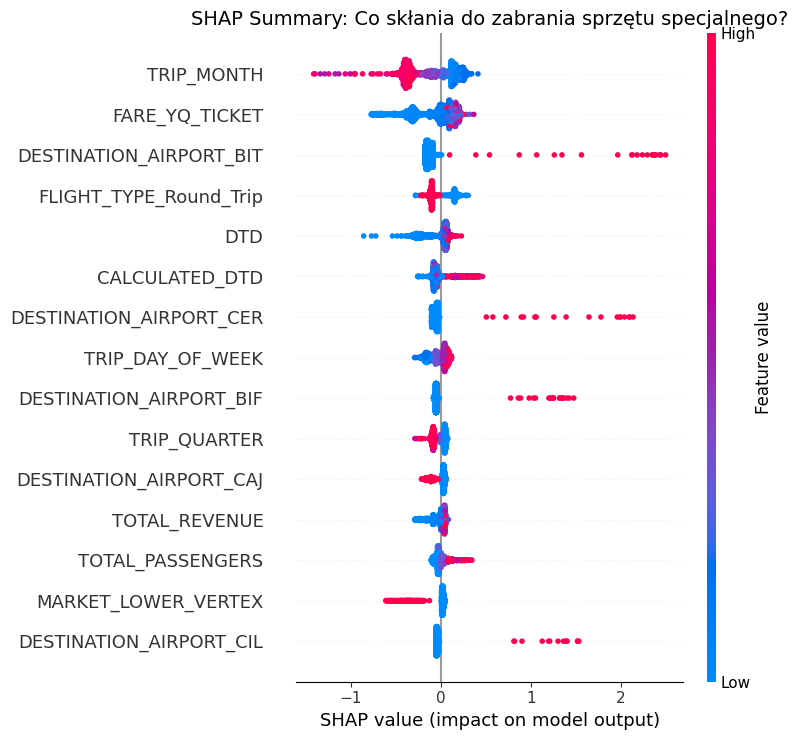

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import shap

warnings.filterwarnings('ignore')

print("1. Wczytywanie danych i podział (TARGET_SPECIAL_EQUIPMENT)...")
df_final = pd.read_parquet('flight_data_ml_ready.parquet')

# Zmieniamy cel na Sprzęt Specjalny (jeśli kolumna nazywa się inaczej, np. TARGET_EQUIPMENT, popraw to)
y = df_final['TARGET_SPECIAL_EQUIPMENT'] 
target_cols = [col for col in df_final.columns if col.startswith('TARGET_')]
X = df_final.drop(columns=target_cols)

# Oczyszczanie nazw
X = X.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("2. Uczenie WERSJI 2.0 dla SPRZĘTU (Lasso L1 i Płytsze Drzewa)...")
# Wyrównanie klas - klasa ekstremalnie rzadka
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
print(f"(Info: Waga klasy pozytywnej wynosi: {pos_weight:.1f})")

xgb_model_eq_v2 = xgb.XGBClassifier(
    n_estimators=300,          
    learning_rate=0.03,        
    max_depth=4,               
    colsample_bytree=0.8,      
    scale_pos_weight=pos_weight, 
    reg_alpha=50,              # POTĘŻNE LASSO (L1) - odrzucamy szum
    reg_lambda=10,             
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model_eq_v2.fit(X_train, y_train)

print("3. Analiza Progu (Cel biznesowy: Precyzja ~10%)...")
y_probs_eq_v2 = xgb_model_eq_v2.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_eq_v2)

# Celujemy w 10% precyzji
target_precision = 0.10
try:
    optimal_idx = np.where(precisions >= target_precision)[0][0]
    optimal_threshold = thresholds[optimal_idx]
except IndexError:
    optimal_idx = np.argmax(precisions)
    optimal_threshold = thresholds[optimal_idx]

y_pred_eq_v2 = (y_probs_eq_v2 >= optimal_threshold).astype(int)

print(f"\n--- RAPORT MODELU SPRZĘT v2 (Próg: {optimal_threshold*100:.1f}%) ---")
print(classification_report(y_test, y_pred_eq_v2, target_names=['Brak Sprzętu (0)', 'Kupi Sprzęt (1)']))

# --- EFEKT EKSTREMALNEJ REGULARYZACJI ---
print("\n--- EFEKT EKSTREMALNEGO LASSO (L1=50) DLA SPRZĘTU ---")
used_features = xgb_model_eq_v2.get_booster().get_fscore()
num_used = len(used_features)
num_total = X.shape[1]
print(f"Liczba kolumn na wejściu: {num_total}")
print(f"Kolumny użyte (przetrwały): {num_used}")
print(f"Kolumny wyzerowane (usunięte): {num_total - num_used}")

# --- MAGIA SHAP: Kto lata z rowerem/nartami? ---
print("\n--- GENEROWANIE WYKRESÓW WYJAŚNIALNOŚCI (SHAP) ---")
X_sample = X_test.head(2000)

explainer = shap.TreeExplainer(xgb_model_eq_v2)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(12, 8))
plt.title('SHAP Summary: Co skłania do zabrania sprzętu specjalnego?', fontsize=14)
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.tight_layout()
plt.show()